In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1430s 8us/step
X_train: (50000, 32, 32, 3)
y_train: (50000, 1)
X_test : (10000, 32, 32, 3)
y_test : (10000, 1)


In [3]:

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

print("Number of classes:", len(class_names))

for i, name in enumerate(class_names):
    print(i, ":", name)

Number of classes: 10
0 : airplane
1 : automobile
2 : bird
3 : cat
4 : deer
5 : dog
6 : frog
7 : horse
8 : ship
9 : truck


In [4]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


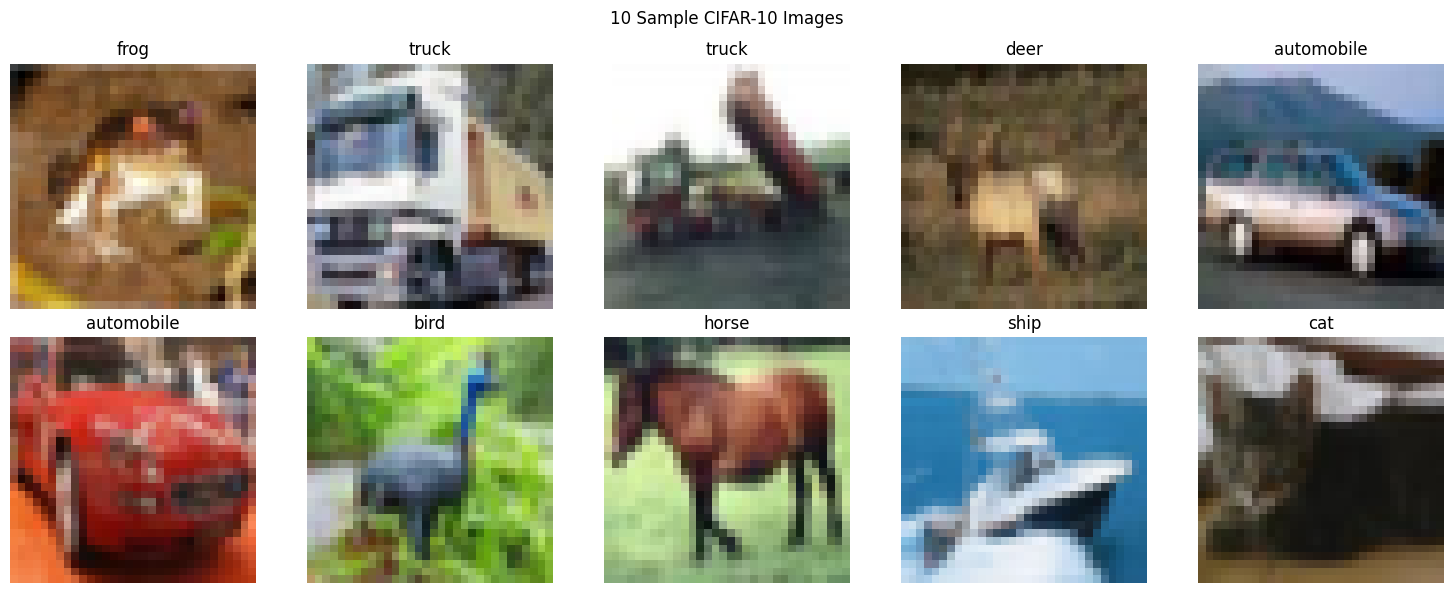

In [5]:
plt.figure(figsize=(15, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(X_train[i])

    label = y_train[i][0]
    plt.title(class_names[label])

    plt.axis("off")

plt.suptitle("10 Sample CIFAR-10 Images")
plt.tight_layout()
plt.show()

In [6]:
print("Training images :", X_train.shape[0])
print("Testing images  :", X_test.shape[0])
print("Image size      :", X_train.shape[1:])
print("Number of classes:", len(class_names))

Training images : 50000
Testing images  : 10000
Image size      : (32, 32, 3)
Number of classes: 10


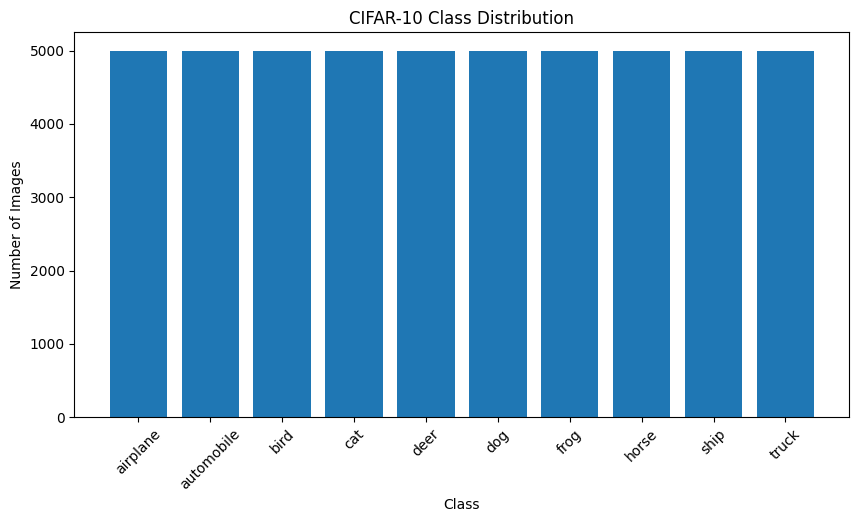

In [7]:
class_counts = np.bincount(y_train.flatten())

plt.figure(figsize=(10, 5))

plt.bar(class_names, class_counts)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("CIFAR-10 Class Distribution")

plt.xticks(rotation=45)
plt.show()

In [8]:
for i in range(10):
    print(f"{class_names[i]:12s} : {class_counts[i]}")

airplane     : 5000
automobile   : 5000
bird         : 5000
cat          : 5000
deer         : 5000
dog          : 5000
frog         : 5000
horse        : 5000
ship         : 5000
truck        : 5000


In [10]:
input_layer = tf.keras.Input(shape=(32, 32, 3))

conv3 = layers.Conv2D(
    16, (3, 3), padding="valid"
)(input_layer)

conv5 = layers.Conv2D(
    16, (5, 5), padding="valid"
)(input_layer)

conv7 = layers.Conv2D(
    16, (7, 7), padding="valid"
)(input_layer)

kernel_model = models.Model(
    inputs=input_layer,
    outputs=[conv3, conv5, conv7]
)

outputs = kernel_model.predict(
    X_train[:1],
    verbose=0
)

print("3x3:", outputs[0].shape)
print("5x5:", outputs[1].shape)
print("7x7:", outputs[2].shape)

3x3: (1, 30, 30, 16)
5x5: (1, 28, 28, 16)
7x7: (1, 26, 26, 16)


In [12]:
def output_size(N, F, P, S):
    return ((N - F + 2 * P) // S) + 1

In [13]:
def output_size(input_size, kernel_size, padding, stride):
    return int(((input_size - kernel_size + 2 * padding) / stride) + 1)

print("3x3 kernel")
print()

print(
    "Stride 1, Valid:",
    output_size(32, 3, 0, 1),
    "x",
    output_size(32, 3, 0, 1)
)

print(
    "Stride 2, Valid:",
    output_size(32, 3, 0, 2),
    "x",
    output_size(32, 3, 0, 2)
)

print("Stride 1, Same: 32 x 32")
print("Stride 2, Same: 16 x 16")

3x3 kernel

Stride 1, Valid: 30 x 30
Stride 2, Valid: 15 x 15
Stride 1, Same: 32 x 32
Stride 2, Same: 16 x 16


In [14]:
input_layer = tf.keras.Input(
    shape=(32, 32, 3)
)

valid = layers.Conv2D(
    16,
    3,
    strides=1,
    padding="valid"
)(input_layer)

same = layers.Conv2D(
    16,
    3,
    strides=1,
    padding="same"
)(input_layer)

stride2 = layers.Conv2D(
    16,
    3,
    strides=2,
    padding="same"
)(input_layer)

stride_model = models.Model(
    input_layer,
    [valid, same, stride2]
)

result = stride_model.predict(
    X_train[:1],
    verbose=0
)

print("Valid, stride 1:", result[0].shape)
print("Same, stride 1 :", result[1].shape)
print("Same, stride 2 :", result[2].shape)

Valid, stride 1: (1, 30, 30, 16)
Same, stride 1 : (1, 32, 32, 16)
Same, stride 2 : (1, 16, 16, 16)


In [15]:
feature_input = tf.keras.Input(
    shape=(32, 32, 3)
)

first_conv = layers.Conv2D(
    16,
    (3, 3),
    padding="same",
    activation="relu"
)(feature_input)

feature_model = models.Model(
    inputs=feature_input,
    outputs=first_conv
)

feature_maps = feature_model.predict(
    X_test[:1],
    verbose=0
)

print("Feature map shape:", feature_maps.shape)

Feature map shape: (1, 32, 32, 16)


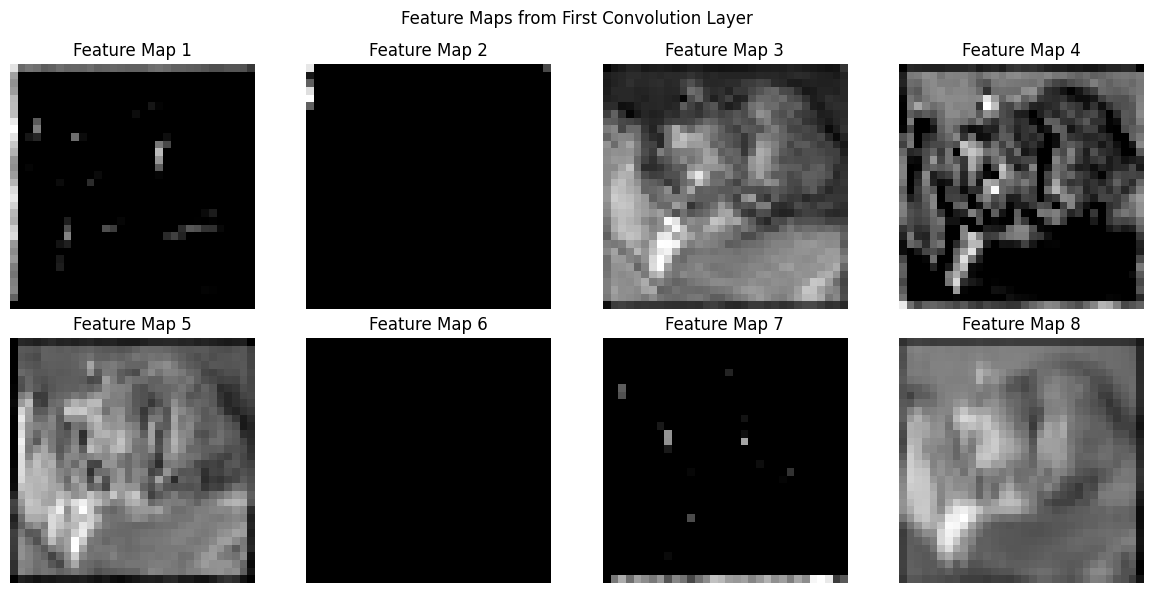

In [16]:
plt.figure(figsize=(12, 6))

for i in range(8):

    plt.subplot(2, 4, i + 1)

    plt.imshow(
        feature_maps[0, :, :, i],
        cmap="gray"
    )

    plt.title("Feature Map " + str(i + 1))
    plt.axis("off")

plt.suptitle("Feature Maps from First Convolution Layer")
plt.tight_layout()
plt.show()

In [17]:
sample = X_test[:1]

max_pool = layers.MaxPooling2D(
    pool_size=(2, 2)
)

average_pool = layers.AveragePooling2D(
    pool_size=(2, 2)
)

max_output = max_pool(sample)
average_output = average_pool(sample)

print("Original :", sample.shape)
print("Max Pool :", max_output.shape)
print("Avg Pool :", average_output.shape)

Original : (1, 32, 32, 3)
Max Pool : (1, 16, 16, 3)
Avg Pool : (1, 16, 16, 3)


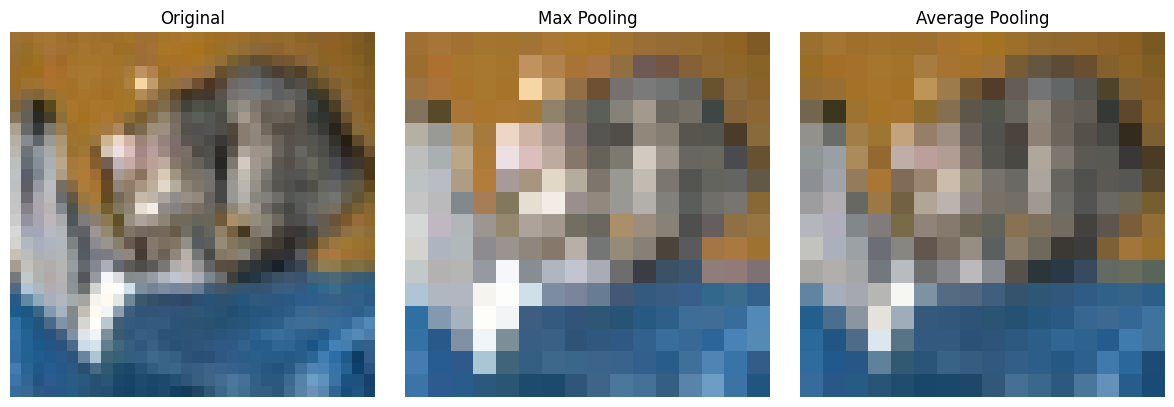

In [18]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(sample[0])
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(max_output[0])
plt.title("Max Pooling")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(average_output[0])
plt.title("Average Pooling")
plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
model = models.Sequential([

    # Input
    layers.Input(shape=(32, 32, 3)),

    # Convolution 1
    layers.Conv2D(
        16,
        (3, 3),
        padding="same"
    ),

    # ReLU
    layers.ReLU(),

    # Max Pooling 1
    layers.MaxPooling2D(
        (2, 2)
    ),

    # Convolution 2
    layers.Conv2D(
        32,
        (3, 3),
        padding="same"
    ),

    # ReLU
    layers.ReLU(),

    # Max Pooling 2
    layers.MaxPooling2D(
        (2, 2)
    ),

    # Flatten
    layers.Flatten(),

    # Dense
    layers.Dense(
        128,
        activation="relu"
    ),

    # Softmax output
    layers.Dense(
        10,
        activation="softmax"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268,650 (1.02 MB)

 Trainable params: 268,650 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [21]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.4734 - loss: 1.4720 - val_accuracy: 0.5684 - val_loss: 1.2401
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5961 - loss: 1.1439 - val_accuracy: 0.6302 - val_loss: 1.0583
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6479 - loss: 1.0056 - val_accuracy: 0.6640 - val_loss: 0.9750
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6807 - loss: 0.9096 - val_accuracy: 0.6570 - val_loss: 0.9952
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7086 - loss: 0.8372 - val_accuracy: 0.6840 - val_loss: 0.9184
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7275 - loss: 0.7699 - val_accuracy: 0.6742 - val_loss: 0.9428
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7524 - loss: 0.7023 - val_accuracy: 0.6942 - val_loss: 0.8929
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7720 - loss: 0.6458 -

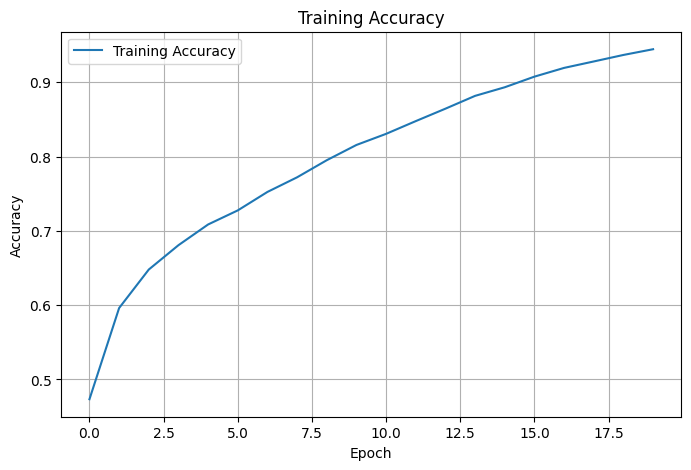

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")

plt.legend()
plt.grid()

plt.show()

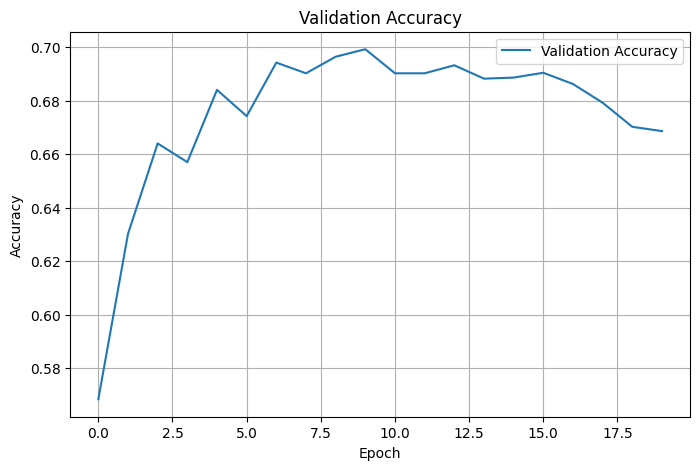

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

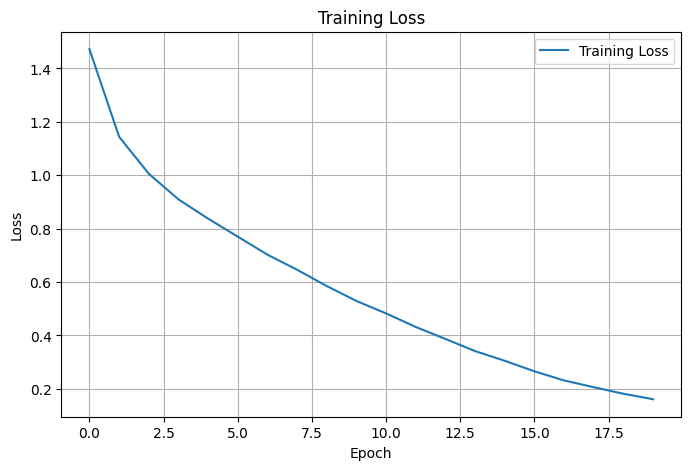

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.legend()
plt.grid()

plt.show()

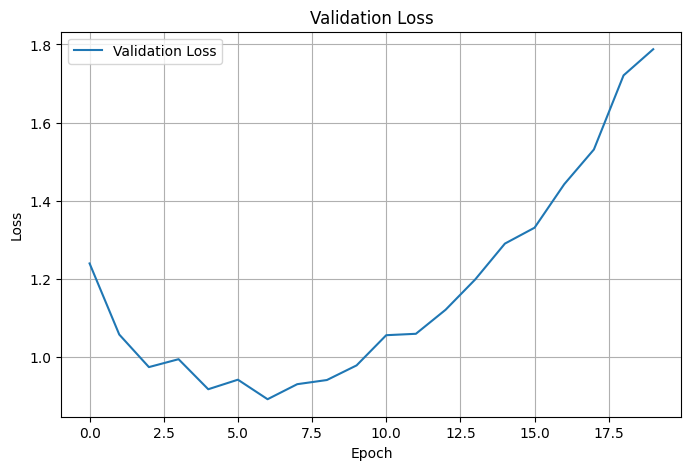

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss")

plt.legend()
plt.grid()

plt.show()

In [26]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6620 - loss: 1.8141
Test Loss: 1.814131498336792
Test Accuracy: 0.6620000004768372


In [27]:
y_probability = model.predict(
    X_test,
    verbose=1
)

y_pred = np.argmax(
    y_probability,
    axis=1
)

y_true = y_test.flatten()

print("Predictions generated successfully.")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predictions generated successfully.


In [28]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Accuracy : 0.662
Precision: 0.6769298746510575
Recall   : 0.662
F1-score : 0.6661746588713855


In [29]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    airplane       0.74      0.69      0.71      1000
  automobile       0.82      0.74      0.78      1000
        bird       0.59      0.49      0.54      1000
         cat       0.42      0.56      0.48      1000
        deer       0.56      0.69      0.61      1000
         dog       0.57      0.54      0.56      1000
        frog       0.78      0.66      0.71      1000
       horse       0.68      0.74      0.71      1000
        ship       0.85      0.75      0.80      1000
       truck       0.77      0.76      0.76      1000

    accuracy                           0.66     10000
   macro avg       0.68      0.66      0.67     10000
weighted avg       0.68      0.66      0.67     10000



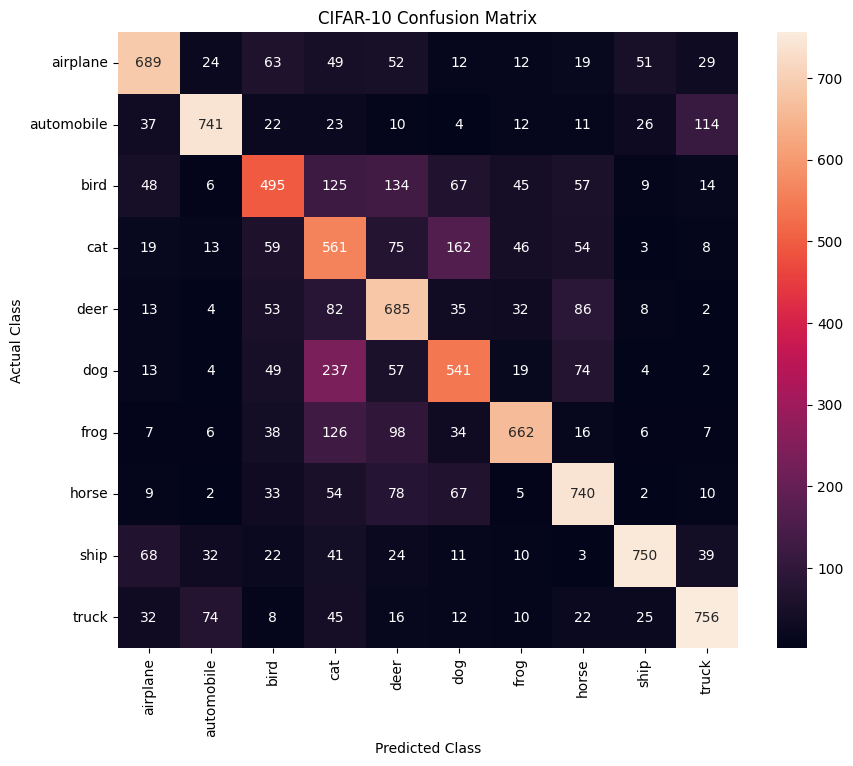

In [30]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("CIFAR-10 Confusion Matrix")

plt.show()

In [31]:
kernel_size = 3
input_channels = 3
filters = 16

parameters = (
    kernel_size * kernel_size * input_channels + 1
) * filters

print("Parameters in first Conv2D layer:", parameters)

Parameters in first Conv2D layer: 448


In [32]:
print("Total model parameters:", model.count_params())

Total model parameters: 268650


In [33]:
N = 64
F = 5
P = 2
S = 2

result = output_size(N, F, P, S)

print("Output size:", result, "x", result)

Output size: 32 x 32


In [34]:
parameters = (
    3 * 3 * 3 + 1
) * 64

print("Trainable parameters:", parameters)


Trainable parameters: 1792


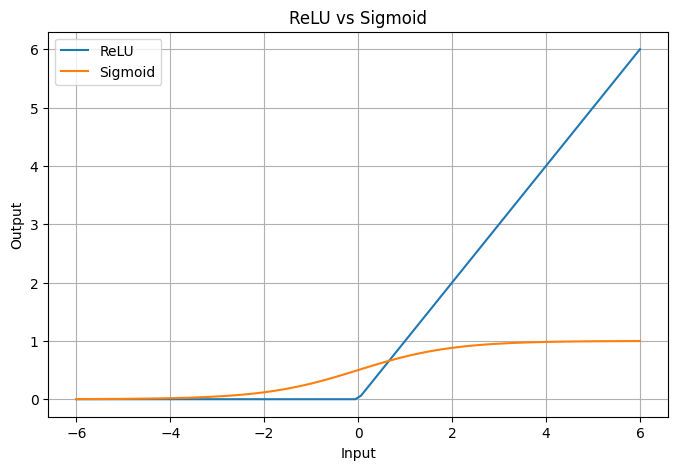

In [35]:
x = np.linspace(-6, 6, 100)

relu = np.maximum(0, x)

sigmoid = 1 / (1 + np.exp(-x))

plt.figure(figsize=(8, 5))

plt.plot(x, relu, label="ReLU")
plt.plot(x, sigmoid, label="Sigmoid")

plt.xlabel("Input")
plt.ylabel("Output")
plt.title("ReLU vs Sigmoid")

plt.legend()
plt.grid()

plt.show()

In [36]:
avg_model = models.Sequential([

    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(
        16,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    layers.AveragePooling2D(
        (2, 2)
    ),

    layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    layers.AveragePooling2D(
        (2, 2)
    ),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dense(
        10,
        activation="softmax"
    )
])

avg_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [37]:
avg_history = avg_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.4375 - loss: 1.5527 - val_accuracy: 0.5138 - val_loss: 1.3559
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5514 - loss: 1.2527 - val_accuracy: 0.5850 - val_loss: 1.1627
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6067 - loss: 1.1038 - val_accuracy: 0.6138 - val_loss: 1.0688
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6476 - loss: 0.9969 - val_accuracy: 0.6612 - val_loss: 0.9703
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6716 - loss: 0.9283 - val_accuracy: 0.6580 - val_loss: 0.9835
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6956 - loss: 0.8632 - val_accuracy: 0.6802 - val_loss: 0.9360
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7147 - loss: 0.8110 - val_accuracy: 0.6862 - val_loss: 0.9185
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7328 - loss: 0.7603 -

In [38]:
max_loss, max_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

avg_loss, avg_accuracy = avg_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Max Pooling Accuracy    :", max_accuracy)
print("Average Pooling Accuracy:", avg_accuracy)

Max Pooling Accuracy    : 0.6620000004768372
Average Pooling Accuracy: 0.6819999814033508


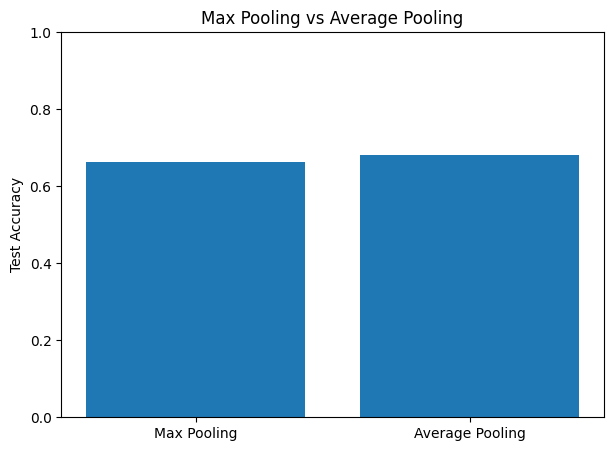

In [39]:
plt.figure(figsize=(7, 5))

plt.bar(
    ["Max Pooling", "Average Pooling"],
    [max_accuracy, avg_accuracy]
)

plt.ylabel("Test Accuracy")
plt.title("Max Pooling vs Average Pooling")

plt.ylim(0, 1)

plt.show()

In [40]:
model_64 = models.Sequential([

    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dense(
        10,
        activation="softmax"
    )
])

model_64.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_64.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 564,426 (2.15 MB)

 Trainable params: 564,426 (2.15 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
import time

start_time = time.time()

history_64 = model_64.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    verbose=1
)

training_time_64 = time.time() - start_time

print("Training time:", training_time_64, "seconds")

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.4927 - loss: 1.4127 - val_accuracy: 0.5940 - val_loss: 1.1484
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6413 - loss: 1.0197 - val_accuracy: 0.6502 - val_loss: 1.0165
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6951 - loss: 0.8723 - val_accuracy: 0.6906 - val_loss: 0.8937
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7319 - loss: 0.7656 - val_accuracy: 0.7000 - val_loss: 0.8784
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7644 - loss: 0.6763 - val_accuracy: 0.7050 - val_loss: 0.8629
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7918 - loss: 0.5964 - val_accuracy: 0.7234 - val_loss: 0.8520
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8162 - loss: 0.5207 - val_accuracy: 0.7246 - val_loss: 0.8595
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8389 - loss: 0.4586 -

In [42]:
loss_64, accuracy_64 = model_64.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("64-filter Test Accuracy:", accuracy_64)
print("64-filter Parameters:", model_64.count_params())

64-filter Test Accuracy: 0.6875
64-filter Parameters: 564426


In [43]:
print("FILTER COMPARISON")
print("==============================")

print("16-filter model")
print("Accuracy   :", test_accuracy)
print("Parameters :", model.count_params())

print()

print("64-filter model")
print("Accuracy   :", accuracy_64)
print("Parameters :", model_64.count_params())
print("Training Time:", training_time_64, "seconds")

FILTER COMPARISON
16-filter model
Accuracy   : 0.6620000004768372
Parameters : 268650

64-filter model
Accuracy   : 0.6875
Parameters : 564426
Training Time: 128.50361514091492 seconds


In [44]:
training_accuracy = history.history["accuracy"][-1]

print("========================================")
print("           FINAL RESULTS")
print("========================================")

print(f"Training Accuracy : {training_accuracy:.4f}")
print(f"Testing Accuracy  : {accuracy:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1-score          : {f1:.4f}")
print(f"Parameters        : {model.count_params()}")

           FINAL RESULTS
Training Accuracy : 0.9444
Testing Accuracy  : 0.6620
Precision         : 0.6769
Recall            : 0.6620
F1-score          : 0.6662
Parameters        : 268650


In [45]:
model.save("cifar10_cnn_model.keras")

print("Model saved successfully.")

Model saved successfully.
